In [ ]:
from data_class.co_v1 import MarchMadnessPredictor as pred_1
from data_class.co_v2 import MarchMadnessPredictor as pred_2

In [2]:
predictor = pred_2(data_dir="../../data/2025", gender='M', current_season=2024)

# Load data
predictor.load_data()

Loaded 8 datasets


In [ ]:
# Option 1: Quick single-season backtest 
# Test the 2023 tournament using 5 previous years for training
result_2023 = predictor.backtest_tournament(
    test_season=2023,
    train_seasons=list(range(2018, 2023)),
    include_elo=True,
    include_advanced_stats=True,
    blend_elo=True,
    elo_weight=0.3
)

Optimizing model parameters through backtesting...
New
Using validation seasons: [2019, 2020, 2021, 2022, 2023]

1. Testing ELO blending weights...
Testing ELO weight: 0.0
Backtesting on 2019 tournament...
Calculating ELO ratings from 2012 to 2019...
Calculated ELO ratings for 14 seasons
Calculating advanced team stats from 2014 to 2019...
Calculated advanced stats for 12 seasons
Creating feature dataset...
Created feature dataset with 670 samples
Train accuracy: 1.0000, Log loss: 0.1077
Test accuracy: 0.9552, Log loss: 0.3013

Top 10 important features:
         Feature  Importance
14      RankDiff    0.084317
18    ELOWinProb    0.057373
5     WinPctDiff    0.052349
13  Team2AvgRank    0.048128
17       ELODiff    0.041680
12  Team1AvgRank    0.041156
8        SOSDiff    0.038102
2       SeedDiff    0.035014
48   NetEff_Diff    0.032253
15      Team1ELO    0.020433
Backtesting results for 2019 tournament:
Brier Score: 0.2514
Accuracy: 0.5000
Log Loss: 0.6886
Backtesting on 2020 tourn

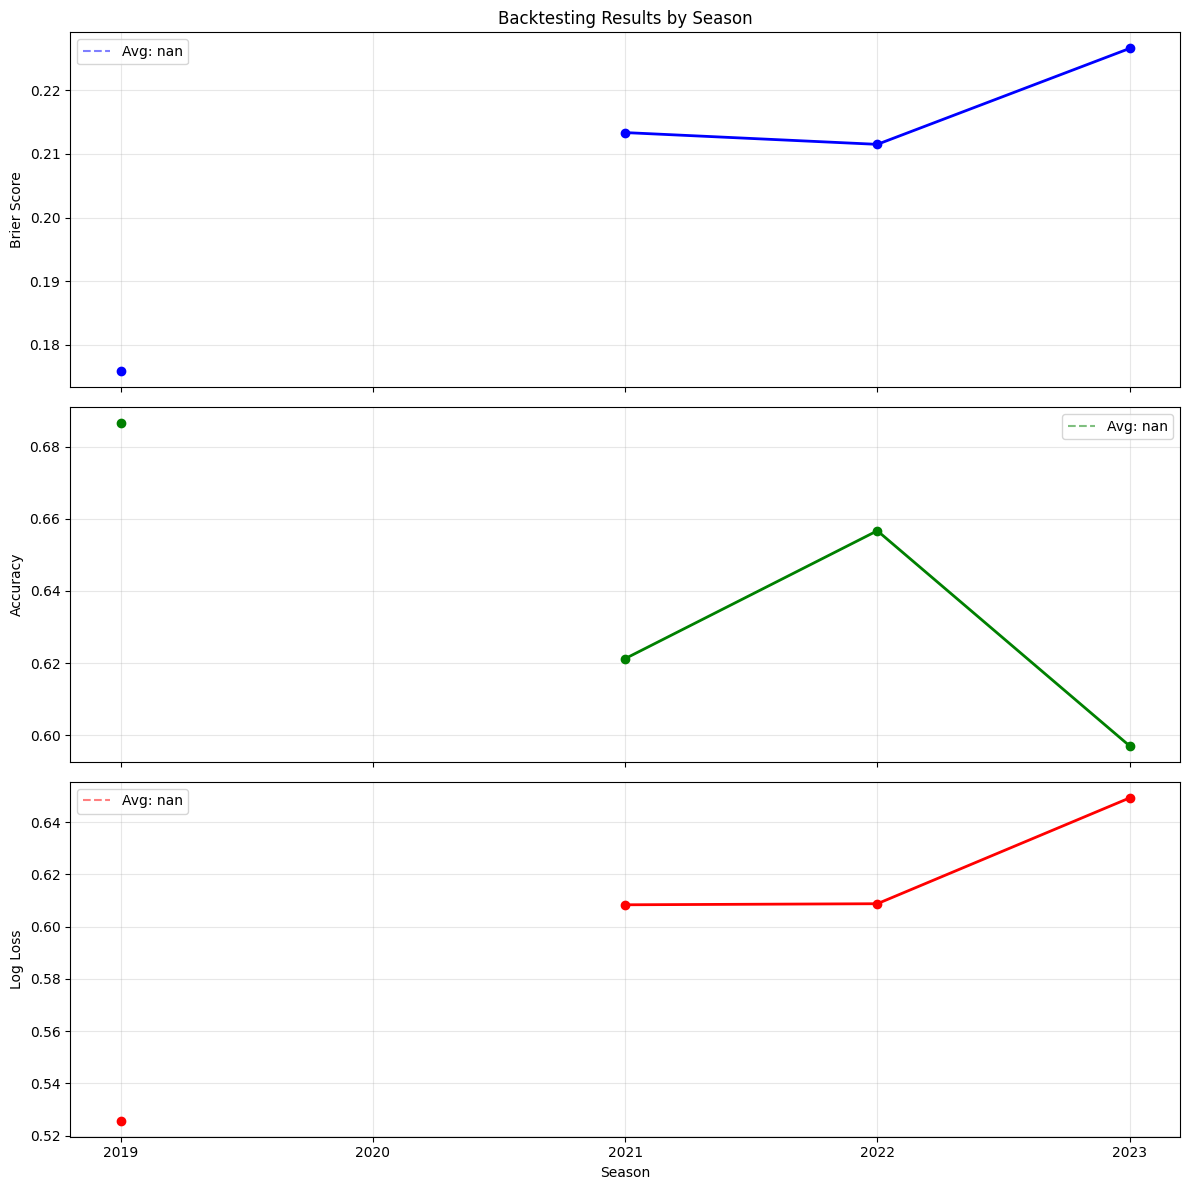


Optimal parameters:
- elo_weight: 1.0
- include_elo: True
- include_advanced_stats: True
- k_factor: 30
- carry_over_factor: 0.75
Final Brier score: 0.2068
Saved final results to optimal_parameters.json


In [3]:
# Option 2: Multi-season backtesting
# Test across the last 5 tournaments (2019-2023)
# multi_results = predictor.backtest_multiple_seasons(
#     test_seasons=list(range(2019, 2024)),
#     lookback_years=5,
#     include_elo=True,
#     include_advanced_stats=True,
#     blend_elo=True,
#     elo_weight=0.3
# )

# Option 3: Test different ELO weights to find optimal value
# elo_test_results = predictor.backtest_multiple_seasons(
#     test_seasons=list(range(2019, 2024)),
#     lookback_years=5,
#     include_elo=True,
#     include_advanced_stats=True,
#     blend_elo=True,
#     test_elo_weights=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
#     visualize=True
# )

# Option 4: Full parameter optimization 
# This will test combinations of parameters to find the best configuration
optimal_params = predictor.optimize_parameters(
    validation_seasons=list(range(2019, 2024)),
    lookback_years=5
)


In [ ]:
# Use the optimal parameters to initialize the final model
# These would normally be stored in a configuration file
best_params = optimal_params['best_result']
predictor.current_season = 2025

In [ ]:
# Calculate ELO with optimal parameters
if best_params.get('include_elo', True):
    predictor.calculate_elo_ratings(
        start_year=2003,
        k_factor=best_params.get('k_factor', 20),
        carry_over_factor=best_params.get('carry_over_factor', 0.75)
    )

In [ ]:
# Calculate advanced stats if needed
if best_params.get('include_advanced_stats', True):
    predictor.calculate_advanced_team_stats(start_season=2003)

In [ ]:
# Create features with optimal parameters
predictor.create_feature_dataset(
    include_elo=best_params.get('include_elo', True),
    include_advanced_stats=best_params.get('include_advanced_stats', True)
)

In [ ]:
# Train model
predictor.train_model()

In [ ]:
# Generate predictions for the current season
predictor.generate_predictions(
    blend_elo=best_params.get('elo_weight', 0) > 0,
    elo_weight=best_params.get('elo_weight', 0.3)
)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch
import numpy as np

# Read the data files
teams_df = pd.read_csv('../../data/2025/MTeams.csv')
seeds_df = pd.read_csv('../../data/2025/MNCAATourneySeeds.csv')
slots_df = pd.read_csv('../../data/2025/MNCAATourneySlots.csv')
predictions_df = pd.read_csv('submission.csv')

# Create a dictionary to map team IDs to team names
team_id_to_name = dict(zip(teams_df['TeamID'], teams_df['TeamName']))

# Filter data for the 2024 tournament
seeds_2024 = seeds_df[seeds_df['Season'] == 2024]
slots_2024 = slots_df[slots_df['Season'] == 2024]

# Function to parse prediction IDs
def parse_prediction_id(pred_id):
    parts = pred_id.split('_')
    year = parts[0]
    team1_id = parts[1]
    team2_id = parts[2]
    return year, team1_id, team2_id

# Create a dictionary for seed to team ID mapping
seed_to_team_id = dict(zip(seeds_2024['Seed'], seeds_2024['TeamID']))

# Create prediction lookup dictionary
prediction_lookup = {}
for _, row in predictions_df.iterrows():
    year, team1_id, team2_id = parse_prediction_id(row['ID'])
    if year == '2024':
        key = f"{team1_id}_{team2_id}"
        prediction_lookup[key] = row['Pred']
        # Also store the reverse for convenience
        prediction_lookup[f"{team2_id}_{team1_id}"] = 1 - row['Pred']

# Function to get prediction for a matchup
def get_prediction(team1_id, team2_id):
    key = f"{team1_id}_{team2_id}"
    return prediction_lookup.get(key, 0.5)

# Function to resolve team ID from a seed
def get_team_id_from_seed(seed):
    return seed_to_team_id.get(seed, None)

# Function to get team name from ID
def get_team_name(team_id):
    if team_id is None:
        return "TBD"
    return team_id_to_name.get(int(team_id), f"Unknown ({team_id})")

# Extract regions from the seed data
regions = set([seed[0] for seed in seeds_2024['Seed']])
print(f"Tournament Regions: {regions}")

# Function to create the bracket visualization
def create_bracket_visualization():
    # Set up the figure
    fig, ax = plt.subplots(figsize=(20, 12))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 70)
    ax.axis('off')
    
    # Title
    ax.text(50, 68, '2024 NCAA Tournament Bracket with Predictions', 
            horizontalalignment='center', fontsize=20, fontweight='bold')
    
    # Define positions for the four regions
    region_positions = {
        'W': (5, 60),   # West region (top-left)
        'X': (55, 60),  # East region (top-right)
        'Y': (5, 30),   # South region (bottom-left)
        'Z': (55, 30)   # Midwest region (bottom-right)
    }
    
    region_names = {
        'W': 'West',
        'X': 'East', 
        'Y': 'South',
        'Z': 'Midwest'
    }
    
    # First, create the initial round brackets (Round of 64)
    seed_pairs = [(1, 16), (8, 9), (5, 12), (4, 13), (6, 11), (3, 14), (7, 10), (2, 15)]
    
    # For each region
    for region in regions:
        base_x, base_y = region_positions[region]
        
        # Draw region name
        ax.text(base_x + 10, base_y + 2, f"{region_names[region]} Region", 
                fontsize=14, fontweight='bold')
        
        # For each seed pair in the first round
        for i, (seed1, seed2) in enumerate(seed_pairs):
            y_pos = base_y - i * 3
            
            # Get team IDs
            team1_seed = f"{region}{seed1:02d}"
            team2_seed = f"{region}{seed2:02d}"
            
            team1_id = get_team_id_from_seed(team1_seed)
            team2_id = get_team_id_from_seed(team2_seed)
            
            team1_name = get_team_name(team1_id)
            team2_name = get_team_name(team2_id)
            
            # Get prediction if both teams are known
            prediction = 0.5
            if team1_id is not None and team2_id is not None:
                prediction = get_prediction(team1_id, team2_id)
            
            # Determine winner
            winner_id = team1_id if prediction >= 0.5 else team2_id
            winner_name = get_team_name(winner_id)
            
            # Draw team names and prediction
            ax.text(base_x, y_pos, f"{seed1}. {team1_name}", fontsize=8, verticalalignment='center')
            ax.text(base_x, y_pos - 0.7, f"{seed2}. {team2_name}", fontsize=8, verticalalignment='center')
            
            # Show prediction percentage
            if prediction >= 0.5:
                pred_text = f"{prediction*100:.1f}%"
            else:
                pred_text = f"{(1-prediction)*100:.1f}%"
            
            ax.text(base_x + 15, y_pos - 0.35, pred_text, fontsize=7, 
                    color='blue', horizontalalignment='center')
            
            # Draw bracket lines
            ax.plot([base_x + 10, base_x + 13], [y_pos, y_pos], 'k-', linewidth=0.5)
            ax.plot([base_x + 10, base_x + 13], [y_pos - 0.7, y_pos - 0.7], 'k-', linewidth=0.5)
            ax.plot([base_x + 13, base_x + 13], [y_pos, y_pos - 0.7], 'k-', linewidth=0.5)
            ax.plot([base_x + 13, base_x + 17], [y_pos - 0.35, y_pos - 0.35], 'k-', linewidth=0.5)
            
            # Show winner
            ax.text(base_x + 18, y_pos - 0.35, winner_name, fontsize=8, 
                    color='red' if prediction >= 0.7 or prediction <= 0.3 else 'black')
    
    # Add rounds labels
    rounds = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite 8', 'Final 4', 'Championship']
    x_positions = [12, 22, 32, 42, 50, 50]
    y_positions = [65, 65, 65, 65, 40, 20]
    
    for round_name, x_pos, y_pos in zip(rounds, x_positions, y_positions):
        ax.text(x_pos, y_pos, round_name, fontsize=12, fontweight='bold', 
                horizontalalignment='center')
    
    # Save the visualization
    plt.tight_layout()
    plt.savefig('NCAA_Tournament_Bracket_2024.png', dpi=300, bbox_inches='tight')
    plt.close()

# Create the visualization
create_bracket_visualization()

print("NCAA Tournament bracket visualization created!")

# More advanced version would include all rounds and proper connections between games,
# but this simple version shows the first round with predictions.

Tournament Regions: {'Y', 'X', 'Z', 'W'}
NCAA Tournament bracket visualization created!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.path import Path
import matplotlib.patches as patches

# Function to convert win probability to point spread
def prob_to_spread(p):
    """Convert win probability to point spread"""
    if p == 0.5:
        return 0
    if p < 0.001:
        p = 0.001
    if p > 0.999:
        p = 0.999
    return -math.log(1/p - 1) * (10/math.log(10))

# Read the data files
teams_df = pd.read_csv('../../data/2025/MTeams.csv')
seeds_df = pd.read_csv('../../data/2025/MNCAATourneySeeds.csv')
slots_df = pd.read_csv('../../data/2025/MNCAATourneySlots.csv')
predictions_df = pd.read_csv('submission.csv')

# Create a dictionary to map team IDs to team names
team_id_to_name = dict(zip(teams_df['TeamID'], teams_df['TeamName']))

# Filter data for the 2024 tournament
seeds_2024 = seeds_df[seeds_df['Season'] == 2024].copy()
slots_2024 = slots_df[slots_df['Season'] == 2024].copy()

# Convert TeamID to string for consistent handling
seeds_2024['TeamID'] = seeds_2024['TeamID'].astype(str)

# Create a dictionary for seed to team ID mapping
seed_to_team_id = dict(zip(seeds_2024['Seed'], seeds_2024['TeamID']))
team_id_to_seed = dict(zip(seeds_2024['TeamID'], seeds_2024['Seed']))

# Function to parse prediction IDs
def parse_prediction_id(pred_id):
    parts = pred_id.split('_')
    year = parts[0]
    team1_id = parts[1]
    team2_id = parts[2]
    return year, team1_id, team2_id

# Create prediction lookup dictionary
prediction_lookup = {}
for _, row in predictions_df.iterrows():
    year, team1_id, team2_id = parse_prediction_id(row['ID'])
    if year == '2024':
        key = f"{team1_id}_{team2_id}"
        prediction_lookup[key] = row['Pred']

# Function to get prediction for a matchup
def get_prediction(team1_id, team2_id):
    key = f"{team1_id}_{team2_id}"
    if key in prediction_lookup:
        return prediction_lookup[key]
    
    # Try reverse order
    key_reverse = f"{team2_id}_{team1_id}"
    if key_reverse in prediction_lookup:
        return 1 - prediction_lookup[key_reverse]
    
    # If no prediction is found, default to 0.5
    return 0.5

# Create a dictionary to track the winners for each slot
slot_winners = {}

# Function to determine winner of a matchup
def determine_winner(team1_id, team2_id):
    if team1_id is None or team2_id is None:
        return team1_id if team2_id is None else team2_id
    
    prediction = get_prediction(team1_id, team2_id)
    return team1_id if prediction >= 0.5 else team2_id

# Process the slots to determine winners for each round
def process_tournament():
    # Start with the first round (Round of 64)
    first_round_slots = [slot for slot in slots_2024['Slot'] if slot.startswith('R1')]
    
    # Sort slots to ensure correct order
    first_round_slots.sort()
    
    # Process each round
    rounds = ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']
    
    for round_idx, round_prefix in enumerate(rounds):
        current_round_slots = [slot for slot in slots_2024['Slot'] if slot.startswith(round_prefix)]
        current_round_slots.sort()
        
        for slot in current_round_slots:
            # Get the slot info
            slot_info = slots_2024[slots_2024['Slot'] == slot].iloc[0]
            strong_seed = slot_info['StrongSeed']
            weak_seed = slot_info['WeakSeed']
            
            # Get team IDs for the matchup
            if strong_seed in seed_to_team_id:
                team1_id = seed_to_team_id[strong_seed]
            else:
                # This seed comes from a previous round winner
                team1_id = slot_winners.get(strong_seed, None)
            
            if weak_seed in seed_to_team_id:
                team2_id = seed_to_team_id[weak_seed]
            else:
                # This seed comes from a previous round winner
                team2_id = slot_winners.get(weak_seed, None)
            
            # Determine the winner
            winner_id = determine_winner(team1_id, team2_id)
            
            # Store the winner for this slot
            slot_winners[slot] = winner_id
    
    return slot_winners

# Process the tournament to determine winners
slot_winners = process_tournament()

# Function to get team name from ID
def get_team_name(team_id):
    if team_id is None:
        return "TBD"
    return team_id_to_name.get(int(team_id), f"Unknown ({team_id})")

# Extract regions from the seed data
regions = list(set([seed[0] for seed in seeds_2024['Seed']]))
regions.sort()  # Sort regions for consistent ordering
print(f"Tournament Regions: {regions}")

# Create the bracket visualization
def create_bracket_visualization():
    # Set up the figure with the same aspect ratio as the template
    fig, ax = plt.subplots(figsize=(15, 11))
    
    # Define constants for the bracket positioning
    X_START = 0.05
    X_END = 0.95
    Y_START = 0.05
    Y_END = 0.93
    
    # Make sure the axes match the template
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Add title
    ax.text(0.5, 0.97, 'NCAA TOURNAMENT 2024 WITH PREDICTIONS & SPREADS', 
            horizontalalignment='center', fontsize=18, fontweight='bold')
    
    # Define round positions (x-coordinates)
    round_positions = {
        'R1L': X_START,            # First Round (Left)
        'R2L': X_START + 0.08,     # Second Round (Left)
        'R3L': X_START + 0.16,     # Sweet 16 (Left)
        'R4L': X_START + 0.24,     # Elite 8 (Left)
        'R5L': X_START + 0.32,     # Final Four (Left)
        'R6': 0.5,                # Championship
        'R5R': X_END - 0.32,       # Final Four (Right)
        'R4R': X_END - 0.24,       # Elite 8 (Right)
        'R3R': X_END - 0.16,       # Sweet 16 (Right)
        'R2R': X_END - 0.08,       # Second Round (Right)
        'R1R': X_END               # First Round (Right)
    }
    
    # Add round labels
    round_labels = [
        ('First Round', round_positions['R1L'] + 0.04, 0.95),
        ('Second Round', round_positions['R2L'] + 0.04, 0.95),
        ('Sweet 16', round_positions['R3L'] + 0.04, 0.95),
        ('Elite Eight', round_positions['R4L'] + 0.04, 0.95),
        ('Final Four', round_positions['R5L'] + 0.04, 0.95),
        ('NATIONAL\nCHAMPIONSHIP', round_positions['R6'], 0.95),
        ('Final Four', round_positions['R5R'] + 0.04, 0.95),
        ('Elite Eight', round_positions['R4R'] + 0.04, 0.95),
        ('Sweet 16', round_positions['R3R'] + 0.04, 0.95),
        ('Second Round', round_positions['R2R'] + 0.04, 0.95),
        ('First Round', round_positions['R1R'] + 0.04, 0.95)
    ]
    
    for label, x, y in round_labels:
        ax.text(x, y, label, horizontalalignment='center', 
                fontsize=10, fontweight='bold')
    
    # Draw the champion box at the center
    champion_box = Rectangle((0.45, 0.45), 0.1, 0.05, fill=False, edgecolor='black')
    ax.add_patch(champion_box)
    ax.text(0.5, 0.44, 'CHAMPIONS', horizontalalignment='center', fontsize=10, fontweight='bold')
    
    # Get champion ID from final slot
    champion_id = slot_winners.get('R6W', None)
    champion_name = get_team_name(champion_id)
    champion_seed = team_id_to_seed.get(champion_id, 'TBD') if champion_id else 'TBD'
    
    # Show champion in the center
    if champion_id:
        seed_num = champion_seed[1:].lstrip('0')  # Remove region letter and leading zeros
        ax.text(0.5, 0.47, f"{seed_num}. {champion_name}", 
                horizontalalignment='center', fontsize=9, fontweight='bold')
    
    # Define regions and their positions
    region_y_starts = {
        regions[0]: 0.85,  # Top left region
        regions[1]: 0.85,  # Top right region
        regions[2]: 0.35,  # Bottom left region
        regions[3]: 0.35   # Bottom right region
    }
    
    # Place teams on the bracket
    team_spacing = 0.025  # Vertical spacing between teams
    
    # Process First Round (Round of 64)
    for region_idx, region in enumerate(regions):
        is_right_side = region_idx % 2  # 0 for left side, 1 for right side
        
        # Determine x positions based on side
        x_r1 = round_positions['R1R'] if is_right_side else round_positions['R1L']
        x_r2 = round_positions['R2R'] if is_right_side else round_positions['R2L']
        x_r3 = round_positions['R3R'] if is_right_side else round_positions['R3L']
        x_r4 = round_positions['R4R'] if is_right_side else round_positions['R4L']
        x_r5 = round_positions['R5R'] if is_right_side else round_positions['R5L']
        
        # Determine text alignment
        align = 'right' if is_right_side else 'left'
        
        # Starting y-position for this region
        y_start = region_y_starts[region]
        
        # Add region label
        region_names = {'W': 'West', 'X': 'East', 'Y': 'South', 'Z': 'Midwest'}
        ax.text(x_r3, y_start + 0.03, f"{region_names.get(region, region)} Region", 
                horizontalalignment='center', fontsize=12, fontweight='bold')
        
        # Seed pairs for first round (1v16, 8v9, etc.)
        seed_pairs = [(1, 16), (8, 9), (5, 12), (4, 13), (6, 11), (3, 14), (7, 10), (2, 15)]
        
        # Track positions for connecting lines
        r1_positions = []
        r2_positions = []
        r3_positions = []
        r4_positions = []
        
        # Process each seed pair in the first round
        for pair_idx, (seed1, seed2) in enumerate(seed_pairs):
            # Calculate y position based on region and pair index
            y_pos = y_start - pair_idx * team_spacing * 4
            
            # Format team seeds
            team1_seed = f"{region}{seed1:02d}"
            team2_seed = f"{region}{seed2:02d}"
            
            # Get team IDs
            team1_id = seed_to_team_id.get(team1_seed, None)
            team2_id = seed_to_team_id.get(team2_seed, None)
            
            if team1_id and team2_id:
                # Get team names
                team1_name = get_team_name(team1_id)
                team2_name = get_team_name(team2_id)
                
                # Get prediction
                prediction = get_prediction(team1_id, team2_id)
                
                # Calculate spread
                spread = abs(prob_to_spread(prediction))
                favorite = team1_name if prediction > 0.5 else team2_name
                underdog = team2_name if prediction > 0.5 else team1_name
                spread_text = f"{favorite} by {spread:.1f}"
                
                # Determine winner
                winner_id = team1_id if prediction >= 0.5 else team2_id
                winner_name = get_team_name(winner_id)
                winner_seed = seed1 if prediction >= 0.5 else seed2
                
                # Draw team1 name with seed
                text_x = x_r1 - 0.01 if is_right_side else x_r1 + 0.01
                ax.text(text_x, y_pos, f"{seed1}. {team1_name}", 
                        horizontalalignment=align, fontsize=8)
                
                # Draw team2 name with seed
                ax.text(text_x, y_pos - team_spacing, f"{seed2}. {team2_name}", 
                        horizontalalignment=align, fontsize=8)
                
                # Draw spread information
                spread_x = x_r1 - 0.09 if is_right_side else x_r1 + 0.09
                ax.text(spread_x, y_pos - team_spacing/2, spread_text, 
                        horizontalalignment=align, fontsize=7, color='blue')
                
                # Store position for connecting lines
                midpoint_y = y_pos - team_spacing/2
                r1_positions.append((x_r1, midpoint_y, winner_name, winner_seed))
            
            # Draw bracket lines
            if is_right_side:
                ax.plot([x_r1 - 0.02, x_r1 - 0.04], [y_pos, y_pos], 'k-', linewidth=0.5)
                ax.plot([x_r1 - 0.02, x_r1 - 0.04], [y_pos - team_spacing, y_pos - team_spacing], 'k-', linewidth=0.5)
                ax.plot([x_r1 - 0.04, x_r1 - 0.04], [y_pos, y_pos - team_spacing], 'k-', linewidth=0.5)
                ax.plot([x_r1 - 0.04, x_r2], [y_pos - team_spacing/2, y_pos - team_spacing/2], 'k-', linewidth=0.5)
            else:
                ax.plot([x_r1 + 0.02, x_r1 + 0.04], [y_pos, y_pos], 'k-', linewidth=0.5)
                ax.plot([x_r1 + 0.02, x_r1 + 0.04], [y_pos - team_spacing, y_pos - team_spacing], 'k-', linewidth=0.5)
                ax.plot([x_r1 + 0.04, x_r1 + 0.04], [y_pos, y_pos - team_spacing], 'k-', linewidth=0.5)
                ax.plot([x_r1 + 0.04, x_r2], [y_pos - team_spacing/2, y_pos - team_spacing/2], 'k-', linewidth=0.5)
        
        # Process second round (Round of 32)
        for i in range(0, len(r1_positions), 2):
            if i + 1 < len(r1_positions):
                # Get positions from first round
                _, y1, winner1, seed1 = r1_positions[i]
                _, y2, winner2, seed2 = r1_positions[i+1]
                
                # Calculate midpoint
                y_mid = (y1 + y2) / 2
                
                # Get team IDs for these winners (need to look up from slots)
                # For simplicity, we'll use the calculated winners from above
                r2_slot = f"R2{region}{i//2+1}"
                winner_id = slot_winners.get(r2_slot, None)
                winner_name = get_team_name(winner_id)
                
                if winner_id:
                    # Lookup the teams that played in this game
                    slot_info = slots_2024[slots_2024['Slot'] == r2_slot].iloc[0]
                    team1_slot = slot_info['StrongSeed']
                    team2_slot = slot_info['WeakSeed']
                    
                    team1_id = slot_winners.get(team1_slot, None) if team1_slot.startswith('R') else seed_to_team_id.get(team1_slot, None)
                    team2_id = slot_winners.get(team2_slot, None) if team2_slot.startswith('R') else seed_to_team_id.get(team2_slot, None)
                    
                    if team1_id and team2_id:
                        # Get the prediction
                        prediction = get_prediction(team1_id, team2_id)
                        
                        # Calculate spread
                        spread = abs(prob_to_spread(prediction))
                        team1_name = get_team_name(team1_id)
                        team2_name = get_team_name(team2_id)
                        favorite = team1_name if prediction > 0.5 else team2_name
                        underdog = team2_name if prediction > 0.5 else team1_name
                        spread_text = f"{favorite} by {spread:.1f}"
                        
                        # Draw spread information
                        spread_x = x_r2 - 0.05 if is_right_side else x_r2 + 0.05
                        ax.text(spread_x, y_mid, spread_text, 
                                horizontalalignment=align, fontsize=6, color='blue')
                
                # Draw the winner in the second round
                text_x = x_r2 - 0.01 if is_right_side else x_r2 + 0.01
                if winner_id:
                    winner_seed_text = team_id_to_seed.get(winner_id, "?")[1:].lstrip('0')
                    ax.text(text_x, y_mid, f"{winner_seed_text}. {winner_name}", 
                            horizontalalignment=align, fontsize=8)
                
                # Draw connecting lines
                if is_right_side:
                    ax.plot([x_r2, x_r2 - 0.02], [y1, y1], 'k-', linewidth=0.5)
                    ax.plot([x_r2, x_r2 - 0.02], [y2, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r2 - 0.02, x_r2 - 0.02], [y1, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r2 - 0.02, x_r3], [y_mid, y_mid], 'k-', linewidth=0.5)
                else:
                    ax.plot([x_r2, x_r2 + 0.02], [y1, y1], 'k-', linewidth=0.5)
                    ax.plot([x_r2, x_r2 + 0.02], [y2, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r2 + 0.02, x_r2 + 0.02], [y1, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r2 + 0.02, x_r3], [y_mid, y_mid], 'k-', linewidth=0.5)
                
                # Store position for connecting to Sweet 16
                r2_positions.append((x_r2, y_mid, winner_name))
        
        # Process Sweet 16
        for i in range(0, len(r2_positions), 2):
            if i + 1 < len(r2_positions):
                # Get positions from second round
                _, y1, winner1 = r2_positions[i]
                _, y2, winner2 = r2_positions[i+1]
                
                # Calculate midpoint
                y_mid = (y1 + y2) / 2
                
                # Get team IDs for these winners
                r3_slot = f"R3{region}{i//2+1}"
                winner_id = slot_winners.get(r3_slot, None)
                winner_name = get_team_name(winner_id)
                
                if winner_id:
                    # Lookup the teams that played in this game
                    slot_info = slots_2024[slots_2024['Slot'] == r3_slot].iloc[0]
                    team1_slot = slot_info['StrongSeed']
                    team2_slot = slot_info['WeakSeed']
                    
                    team1_id = slot_winners.get(team1_slot, None) if team1_slot.startswith('R') else seed_to_team_id.get(team1_slot, None)
                    team2_id = slot_winners.get(team2_slot, None) if team2_slot.startswith('R') else seed_to_team_id.get(team2_slot, None)
                    
                    if team1_id and team2_id:
                        # Get the prediction
                        prediction = get_prediction(team1_id, team2_id)
                        
                        # Calculate spread
                        spread = abs(prob_to_spread(prediction))
                        team1_name = get_team_name(team1_id)
                        team2_name = get_team_name(team2_id)
                        favorite = team1_name if prediction > 0.5 else team2_name
                        underdog = team2_name if prediction > 0.5 else team1_name
                        spread_text = f"{favorite} by {spread:.1f}"
                        
                        # Draw spread information
                        spread_x = x_r3 - 0.05 if is_right_side else x_r3 + 0.05
                        ax.text(spread_x, y_mid, spread_text, 
                                horizontalalignment=align, fontsize=6, color='blue')
                
                # Draw the winner in the Sweet 16
                text_x = x_r3 - 0.01 if is_right_side else x_r3 + 0.01
                if winner_id:
                    winner_seed_text = team_id_to_seed.get(winner_id, "?")[1:].lstrip('0')
                    ax.text(text_x, y_mid, f"{winner_seed_text}. {winner_name}", 
                            horizontalalignment=align, fontsize=8)
                
                # Draw connecting lines
                if is_right_side:
                    ax.plot([x_r3, x_r3 - 0.02], [y1, y1], 'k-', linewidth=0.5)
                    ax.plot([x_r3, x_r3 - 0.02], [y2, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r3 - 0.02, x_r3 - 0.02], [y1, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r3 - 0.02, x_r4], [y_mid, y_mid], 'k-', linewidth=0.5)
                else:
                    ax.plot([x_r3, x_r3 + 0.02], [y1, y1], 'k-', linewidth=0.5)
                    ax.plot([x_r3, x_r3 + 0.02], [y2, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r3 + 0.02, x_r3 + 0.02], [y1, y2], 'k-', linewidth=0.5)
                    ax.plot([x_r3 + 0.02, x_r4], [y_mid, y_mid], 'k-', linewidth=0.5)
                
                # Store position for connecting to Elite 8
                r3_positions.append((x_r3, y_mid, winner_name))
        
        # Process Elite 8
        if len(r3_positions) >= 2:
            # Get positions from Sweet 16
            _, y1, winner1 = r3_positions[0]
            _, y2, winner2 = r3_positions[1]
            
            # Calculate midpoint
            y_mid = (y1 + y2) / 2
            
            # Get team IDs for these winners
            r4_slot = f"R4{region}"
            winner_id = slot_winners.get(r4_slot, None)
            winner_name = get_team_name(winner_id)
            
            if winner_id:
                # Lookup the teams that played in this game
                slot_info = slots_2024[slots_2024['Slot'] == r4_slot].iloc[0]
                team1_slot = slot_info['StrongSeed']
                team2_slot = slot_info['WeakSeed']
                
                team1_id = slot_winners.get(team1_slot, None) if team1_slot.startswith('R') else seed_to_team_id.get(team1_slot, None)
                team2_id = slot_winners.get(team2_slot, None) if team2_slot.startswith('R') else seed_to_team_id.get(team2_slot, None)
                
                if team1_id and team2_id:
                    # Get the prediction
                    prediction = get_prediction(team1_id, team2_id)
                    
                    # Calculate spread
                    spread = abs(prob_to_spread(prediction))
                    team1_name = get_team_name(team1_id)
                    team2_name = get_team_name(team2_id)
                    favorite = team1_name if prediction > 0.5 else team2_name
                    underdog = team2_name if prediction > 0.5 else team1_name
                    spread_text = f"{favorite} by {spread:.1f}"
                    
                    # Draw spread information
                    spread_x = x_r4 - 0.05 if is_right_side else x_r4 + 0.05
                    ax.text(spread_x, y_mid, spread_text, 
                            horizontalalignment=align, fontsize=6, color='blue')
            
            # Draw the winner in the Elite 8
            text_x = x_r4 - 0.01 if is_right_side else x_r4 + 0.01
            if winner_id:
                winner_seed_text = team_id_to_seed.get(winner_id, "?")[1:].lstrip('0')
                ax.text(text_x, y_mid, f"{winner_seed_text}. {winner_name}", 
                        horizontalalignment=align, fontsize=8)
            
            # Draw connecting lines
            if is_right_side:
                ax.plot([x_r4, x_r4 - 0.02], [y1, y1], 'k-', linewidth=0.5)
                ax.plot([x_r4, x_r4 - 0.02], [y2, y2], 'k-', linewidth=0.5)
                ax.plot([x_r4 - 0.02, x_r4 - 0.02], [y1, y2], 'k-', linewidth=0.5)
                ax.plot([x_r4 - 0.02, x_r5], [y_mid, y_mid], 'k-', linewidth=0.5)
            else:
                ax.plot([x_r4, x_r4 + 0.02], [y1, y1], 'k-', linewidth=0.5)
                ax.plot([x_r4, x_r4 + 0.02], [y2, y2], 'k-', linewidth=0.5)
                ax.plot([x_r4 + 0.02, x_r4 + 0.02], [y1, y2], 'k-', linewidth=0.5)
                ax.plot([x_r4 + 0.02, x_r5], [y_mid, y_mid], 'k-', linewidth=0.5)
            
            # Store position for Final Four
            r4_positions.append((x_r4, y_mid, winner_name, winner_id, region))
    
    # Process Final Four
    if len(r4_positions) >= 4:
        # Final Four - Left Side
        _, y1, name1, id1, reg1 = r4_positions[0]  # Top-left region
        _, y2, name2, id2, reg2 = r4_positions[2]  # Bottom-left region
        
        # Calculate midpoint
        y_mid_left = (y1 + y2) / 2
        
        # Get team IDs for these winners
        r5_slot = "R5WX"  # Left side Final Four game
        winner_id_left = slot_winners.get(r5_slot, None)
        winner_name_left = get_team_name(winner_id_left)
        
        if id1 and id2:
            # Get the prediction
            prediction = get_prediction(id1, id2)
            
            # Calculate spread
            spread = abs(prob_to_spread(prediction))
            favorite = name1 if prediction > 0.5 else name2
            underdog = name2 if prediction > 0.5 else name1
            spread_text = f"{favorite} by {spread:.1f}"
            
            # Draw spread information
            spread_x = round_positions['R5L'] + 0.05
            ax.text(spread_x, y_mid_left, spread_text, 
                    horizontalalignment='center', fontsize=6, color='blue')
        
        # Draw the winner in the Final Four left side
        if winner_id_left:
            winner_seed_text = team_id_to_seed.get(winner_id_left, "?")[1:].lstrip('0')
            ax.text(round_positions['R5L'] + 0.05, y_mid_left, f"{winner_seed_text}. {winner_name_left}", 
                    horizontalalignment='center', fontsize=9, fontweight='bold')
        
        # Draw connecting lines for left side
        ax.plot([round_positions['R5L'], round_positions['R5L'] + 0.02], [y1, y1], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5L'], round_positions['R5L'] + 0.02], [y2, y2], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5L'] + 0.02, round_positions['R5L'] + 0.02], [y1, y2], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5L'] + 0.02, round_positions['R6'] - 0.05], [y_mid_left, y_mid_left], 'k-', linewidth=0.5)
        
        # Final Four - Right Side
        _, y3, name3, id3, reg3 = r4_positions[1]  # Top-right region
        _, y4, name4, id4, reg4 = r4_positions[3]  # Bottom-right region
        
        # Calculate midpoint
        y_mid_right = (y3 + y4) / 2
        
        # Get team IDs for these winners
        r5_slot = "R5YZ"  # Right side Final Four game
        winner_id_right = slot_winners.get(r5_slot, None)
        winner_name_right = get_team_name(winner_id_right)
        
        if id3 and id4:
            # Get the prediction
            prediction = get_prediction(id3, id4)
            
            # Calculate spread
            spread = abs(prob_to_spread(prediction))
            favorite = name3 if prediction > 0.5 else name4
            underdog = name4 if prediction > 0.5 else name3
            spread_text = f"{favorite} by {spread:.1f}"
            
            # Draw spread information
            spread_x = round_positions['R5R'] - 0.05
            ax.text(spread_x, y_mid_right, spread_text, 
                    horizontalalignment='center', fontsize=6, color='blue')
        
        # Draw the winner in the Final Four right side
        if winner_id_right:
            winner_seed_text = team_id_to_seed.get(winner_id_right, "?")[1:].lstrip('0')
            ax.text(round_positions['R5R'] - 0.05, y_mid_right, f"{winner_seed_text}. {winner_name_right}", 
                    horizontalalignment='center', fontsize=9, fontweight='bold')
        
        # Draw connecting lines for right side
        ax.plot([round_positions['R5R'], round_positions['R5R'] - 0.02], [y3, y3], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5R'], round_positions['R5R'] - 0.02], [y4, y4], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5R'] - 0.02, round_positions['R5R'] - 0.02], [y3, y4], 'k-', linewidth=0.5)
        ax.plot([round_positions['R5R'] - 0.02, round_positions['R6'] + 0.05], [y_mid_right, y_mid_right], 'k-', linewidth=0.5)
        
        # Championship game
        if winner_id_left and winner_id_right:
            # Get the prediction
            prediction = get_prediction(winner_id_left, winner_id_right)
            
            # Calculate spread
            spread = abs(prob_to_spread(prediction))
            favorite = winner_name_left if prediction > 0.5 else winner_name_right
            underdog = winner_name_right if prediction > 0.5 else winner_name_left
            spread_text = f"{favorite} by {spread:.1f}"
            
            # Draw spread information
            ax.text(round_positions['R6'], 0.55, spread_text, 
                    horizontalalignment='center', fontsize=7, color='blue')
            
            # Connect final four to championship
            ax.plot([round_positions['R6'] - 0.05, round_positions['R6'] - 0.05], [y_mid_left, 0.5], 'k-', linewidth=0.5)
            ax.plot([round_positions['R6'] + 0.05, round_positions['R6'] + 0.05], [y_mid_right, 0.5], 'k-', linewidth=0.5)
            ax.plot([round_positions['R6'] - 0.05, round_positions['R6'] + 0.05], [0.5, 0.5], 'k-', linewidth=0.5)
    
    # Add footer with explanation
    ax.text(0.05, 0.01, 'Predictions show win probabilities converted to point spreads. Blue text indicates the favorite and spread.', 
            fontsize=7)
    
    # Save the visualization
    plt.tight_layout(pad=0.5)
    plt.savefig('NCAA_Tournament_Bracket_2024_with_spreads.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print("NCAA Tournament bracket visualization with spreads created!")

# Create the visualization
create_bracket_visualization()

Tournament Regions: ['W', 'X', 'Y', 'Z']
NCAA Tournament bracket visualization with spreads created!


In [34]:
import os
print(os.getcwd()) 

/Users/conor/Documents/march_madness/notebooks/2025


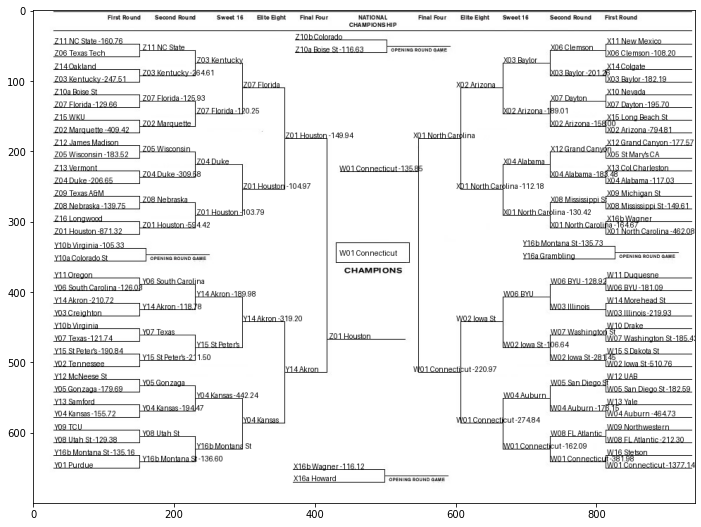

In [18]:
import sys
import os
folder_name = "march_madness"
BASE_DIR = os.path.abspath(".").split(folder_name)[0]+folder_name
DATA_ROOT = os.path.join(BASE_DIR, "data")
sys.path.insert(0, BASE_DIR)

from generate_bracket.generate_bracket import build_bracket #Import from the path

# Read the data files
teams_df = pd.read_csv('../../data/2025/MTeams.csv')
seeds_df = pd.read_csv('../../data/2025/MNCAATourneySeeds.csv')
slots_df = pd.read_csv('../../data/2025/MNCAATourneySlots.csv')
predictions_df = pd.read_csv('submission.csv')

DATA_DIR = "../../data/2025/"
YEAR = 2024

b = build_bracket(
    teamsPath=f"{DATA_DIR}/MTeams.csv",
    seedsPath=f"{DATA_DIR}/MNCAATourneySeeds.csv",
    slotsPath=f"{DATA_DIR}/MNCAATourneySlots.csv",
    submissionPath="submission.csv",
    emptyBracketPath="../../empty_bracket/empty.jpg",
    year=int(YEAR),
    bettingOdds=True
)

In [ ]:
predictor.load_data()

# Option 1: Quick single-season backtest 
# Test the 2023 tournament using 5 previous years for training
result_2023 = predictor.backtest_tournament(
    test_season=2023,
    train_seasons=list(range(2018, 2023)),
    include_elo=True,
    include_advanced_stats=True,
    blend_elo=True,
    elo_weight=0.3
)

# Option 2: Multi-season backtesting
# Test across the last 5 tournaments (2019-2023)
multi_results = predictor.backtest_multiple_seasons(
    test_seasons=list(range(2019, 2024)),
    lookback_years=5,
    include_elo=True,
    include_advanced_stats=True,
    blend_elo=True,
    elo_weight=0.3
)

# Option 3: Test different ELO weights to find optimal value
elo_test_results = predictor.backtest_multiple_seasons(
    test_seasons=list(range(2019, 2024)),
    lookback_years=5,
    include_elo=True,
    include_advanced_stats=True,
    blend_elo=True,
    test_elo_weights=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    visualize=True
)

# Option 4: Full parameter optimization 
# This will test combinations of parameters to find the best configuration
optimal_params = predictor.optimize_parameters(
    validation_seasons=list(range(2019, 2024)),
    lookback_years=5
)

# Use the optimal parameters to initialize the final model
# These would normally be stored in a configuration file
best_params = optimal_params['optimal_params']

# Calculate ELO with optimal parameters
if best_params.get('include_elo', True):
    predictor.calculate_elo_ratings(
        start_year=2003,
        k_factor=best_params.get('k_factor', 20),
        carry_over_factor=best_params.get('carry_over_factor', 0.75)
    )

# Calculate advanced stats if needed
if best_params.get('include_advanced_stats', True):
    predictor.calculate_advanced_team_stats(start_season=2003)

# Create features with optimal parameters
predictor.create_feature_dataset(
    include_elo=best_params.get('include_elo', True),
    include_advanced_stats=best_params.get('include_advanced_stats', True)
)

# Train model
predictor.train_model()

# Generate predictions for the current season
predictor.generate_predictions(
    blend_elo=best_params.get('elo_weight', 0) > 0,
    elo_weight=best_params.get('elo_weight', 0.3)
)

In [ ]:
from data_class.co_v2 import MarchMadnessPredictor as pred_2
predictor_2 = pred_2(data_dir="../data/2025", gender='M', current_season=2025)

# Load data
predictor_2.load_data()
predictor_2.generate_all_matchup_predictions(output_file="all_predictions_men.csv")

Index(['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season'], dtype='object')
Loaded 8 datasets
ELO ratings required for enhanced predictions. Calculating...
Calculating ELO ratings from 2003 to 2025...
Calculated ELO ratings for 23 seasons
Generating predictions for 364 teams (66066 matchups)...
Generated 1000 matchups...
Generated 2000 matchups...
Generated 3000 matchups...


In [ ]:
from data_class.co_v2 import MarchMadnessPredictor as pred_2
predictor_2 = pred_2(data_dir="../data/2025", gender='W', current_season=2025)

# Load data
predictor_2.load_data()
predictor_2.generate_all_matchup_predictions(output_file="all_predictions_women.csv")

Index(['TeamID', 'TeamName'], dtype='object')
Loaded 6 datasets
ELO ratings required for enhanced predictions. Calculating...
Calculating ELO ratings from 2003 to 2024...
Calculated ELO ratings for 22 seasons
Generating predictions for 360 teams (64620 matchups)...
Generated 1000 matchups...
Generated 2000 matchups...
Generated 3000 matchups...
Generated 4000 matchups...
Generated 5000 matchups...
Generated 6000 matchups...
Generated 7000 matchups...
Generated 8000 matchups...
Generated 9000 matchups...
Generated 10000 matchups...
Generated 11000 matchups...
Generated 12000 matchups...
Generated 13000 matchups...
Generated 14000 matchups...
Generated 15000 matchups...
Generated 16000 matchups...
Generated 17000 matchups...
Generated 18000 matchups...
Generated 19000 matchups...
Generated 20000 matchups...
Generated 21000 matchups...
Generated 22000 matchups...
Generated 23000 matchups...
Generated 24000 matchups...
Generated 25000 matchups...
Generated 26000 matchups...
Generated 27000

,ID,Season,Team1ID,Team2ID,Team1Name,Team2Name,Pred
0,2024_3101_3102,2024,3101,3102,Abilene Chr,Air Force,0.513527
1,2024_3101_3103,2024,3101,3103,Abilene Chr,Akron,0.475407
2,2024_3101_3104,2024,3101,3104,Abilene Chr,Alabama,0.216787
3,2024_3101_3105,2024,3101,3105,Abilene Chr,Alabama A&M,0.518622
4,2024_3101_3106,2024,3101,3106,Abilene Chr,Alabama St,0.675708
...,...,...,...,...,...,...,...
64615,2024_3475_3477,2024,3475,3477,Southern Indiana,TX A&M Commerce,0.669482
64616,2024_3475_3478,2024,3475,3478,Southern Indiana,Le Moyne,0.549700
64617,2024_3476_3477,2024,3476,3477,Stonehill,TX A&M Commerce,0.276672
64618,2024_3476_3478,2024,3476,3478,Stonehill,Le Moyne,0.187336


In [7]:
import pandas as pd
df_1 = pd.read_csv("all_predictions_men.csv")
df_2 = pd.read_csv("all_predictions_women.csv")

df = pd.concat([df_1, df_2], axis=0)
df[["ID", "Pred"]].to_csv("submission.csv", index=False)

In [9]:
with open('team_elo_ratings.csv', 'w') as file:
    file.write(f"Season,Team_Id,Day,ELO")
    for k, v in predictor_2.team_elo_ratings.items():
        season, team_id, day = k
        file.write(f"\n{season},{team_id},{day},{v}")


In [ ]:

# Process seeds
predictor.preprocess_seeds()

# Calculate ELO ratings with optimal parameters from previous optimization
predictor.calculate_elo_ratings(
    start_year=2003, 
    k_factor=30,  # From your optimization result
    carry_over_factor=0.75
)

# Calculate advanced stats
predictor.calculate_advanced_team_stats(start_season=2003)

# Backtest the enhanced model on the 2023 tournament
# (Using the most recent completed tournament as an example)
result_2023 = predictor.backtest_enhanced_model(test_season=2023)

# Backtest over several recent tournaments to ensure consistency
all_results = []
improvement_by_season = []

for season in range(2017, 2024):
    print(f"\nTesting {season} tournament:")
    result = predictor.backtest_enhanced_model(test_season=season)
    if result:
        all_results.append(result)
        improvement_by_season.append({
            'Season': season,
            'Improvement': result['brier_improvement']
        })

# Calculate average improvement
if all_results:
    avg_improvement = np.mean([r['brier_improvement'] for r in all_results])
    print(f"\nAverage Brier score improvement: {avg_improvement:.4f}")
    
    # Visualize improvement by season
    seasons = [r['Season'] for r in improvement_by_season]
    improvements = [r['Improvement'] for r in improvement_by_season]
    
    plt.figure(figsize=(10, 6))
    plt.bar(seasons, improvements)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.xlabel('Tournament Season')
    plt.ylabel('Brier Score Improvement')
    plt.title('Enhanced Model Improvement over Pure ELO')
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(improvements):
        plt.text(seasons[i], v + 0.001, f"{v:.4f}", ha='center')
    plt.tight_layout()
    plt.show()

# Generate enhanced predictions for the current tournament
enhanced_predictions = predictor.generate_enhanced_predictions()

# Compare with baseline ELO predictions
baseline_predictions = predictor.generate_predictions(blend_elo=True, elo_weight=1.0)

# Merge and compare the two
merged = pd.merge(
    enhanced_predictions, 
    baseline_predictions,
    on='ID', 
    suffixes=('_enhanced', '_baseline')
)

# Calculate average absolute difference
merged['diff'] = abs(merged['Pred_enhanced'] - merged['Pred_baseline'])
avg_diff = merged['diff'].mean()
max_diff = merged['diff'].max()

print(f"\nComparison of prediction methods:")
print(f"Average difference: {avg_diff:.4f}")
print(f"Maximum difference: {max_diff:.4f}")

# Show matchups with biggest differences
top_diffs = merged.sort_values('diff', ascending=False).head(10)

print("\nTop 10 matchups with biggest prediction differences:")
for _, row in top_diffs.iterrows():
    game_id = row['ID']
    parts = game_id.split('_')
    season, team1, team2 = int(parts[0]), int(parts[1]), int(parts[2])
    
    # Get team names and seeds
    team1_name = predictor.data['teams'][predictor.data['teams']['TeamID'] == team1].iloc[0]['TeamName']
    team2_name = predictor.data['teams'][predictor.data['teams']['TeamID'] == team2].iloc[0]['TeamName']
    
    team1_seed = predictor.seed_lookup.get((season, team1), "?")
    team2_seed = predictor.seed_lookup.get((season, team2), "?")
    
    print(f"{team1_name} ({team1_seed}) vs {team2_name} ({team2_seed}):")
    print(f"  Enhanced: {row['Pred_enhanced']:.4f}, Baseline: {row['Pred_baseline']:.4f}")
    print(f"  Difference: {row['diff']:.4f}")
    
# Save final enhanced predictions
enhanced_predictions.to_csv('final_predictions.csv', index=False)
print("\nSaved final predictions to final_predictions.csv")